Using device: cuda
Data prepared: Train 50000, Val 10000, Test 10000
ANN parameters: 569,226
CNN parameters: 391,370

--- Training Enhanced ANN ---
ANN Epoch 1/20: Train Loss 0.9560, Acc 64.21% | Val Loss 0.6708, Acc 72.95%
ANN Epoch 2/20: Train Loss 0.8576, Acc 68.42% | Val Loss 0.6418, Acc 73.86%
ANN Epoch 3/20: Train Loss 0.8417, Acc 69.04% | Val Loss 0.6388, Acc 74.05%
ANN Epoch 4/20: Train Loss 0.8318, Acc 69.02% | Val Loss 0.6917, Acc 71.65%
ANN Epoch 5/20: Train Loss 0.8315, Acc 69.54% | Val Loss 0.6267, Acc 75.90%
ANN Epoch 6/20: Train Loss 0.8313, Acc 69.31% | Val Loss 0.6523, Acc 75.84%
ANN Epoch 7/20: Train Loss 0.8256, Acc 69.49% | Val Loss 0.6618, Acc 73.91%
ANN Epoch 8/20: Train Loss 0.8327, Acc 69.23% | Val Loss 0.6197, Acc 75.00%
ANN Epoch 9/20: Train Loss 0.8252, Acc 69.59% | Val Loss 0.5967, Acc 77.35%
ANN Epoch 10/20: Train Loss 0.8243, Acc 69.70% | Val Loss 0.6521, Acc 75.50%
ANN Epoch 11/20: Train Loss 0.8251, Acc 69.47% | Val Loss 0.5990, Acc 77.10%
ANN Epoch 12/2

/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:1535: UserWarning: dropout2d: Received a 2-D input to dropout2d, which is deprecated and will result in an error in a future release. To retain the behavior and silence this warning, please use dropout instead. Note that dropout2d exists to provide channel-wise dropout on inputs with 2 spatial dimensions, a channel dimension, and an optional batch dimension (i.e. 3D or 4D inputs).
  warnings.warn(warn_msg)


CNN Epoch 1/20: Train Loss 0.7054, Acc 73.70% | Val Loss 0.4631, Acc 82.11%
CNN Epoch 2/20: Train Loss 0.5340, Acc 80.16% | Val Loss 0.3709, Acc 85.53%
CNN Epoch 3/20: Train Loss 0.5092, Acc 81.11% | Val Loss 0.4212, Acc 83.42%
CNN Epoch 4/20: Train Loss 0.4980, Acc 81.76% | Val Loss 0.3894, Acc 84.57%
CNN Epoch 5/20: Train Loss 0.4882, Acc 82.10% | Val Loss 0.3639, Acc 85.92%
CNN Epoch 6/20: Train Loss 0.4799, Acc 82.44% | Val Loss 0.4010, Acc 84.76%
CNN Epoch 7/20: Train Loss 0.4793, Acc 82.34% | Val Loss 0.3842, Acc 84.82%
CNN Epoch 8/20: Train Loss 0.4747, Acc 82.57% | Val Loss 0.4052, Acc 85.15%
CNN Epoch 9/20: Train Loss 0.4726, Acc 82.73% | Val Loss 0.3440, Acc 86.77%
CNN Epoch 10/20: Train Loss 0.4699, Acc 82.85% | Val Loss 0.3398, Acc 86.84%
CNN Epoch 11/20: Train Loss 0.4715, Acc 82.80% | Val Loss 0.3266, Acc 87.61%
CNN Epoch 12/20: Train Loss 0.4654, Acc 83.02% | Val Loss 0.3813, Acc 85.14%
CNN Epoch 13/20: Train Loss 0.4667, Acc 82.92% | Val Loss 0.3158, Acc 87.94%
CNN Epoc

/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:1535: UserWarning: dropout2d: Received a 2-D input to dropout2d, which is deprecated and will result in an error in a future release. To retain the behavior and silence this warning, please use dropout instead. Note that dropout2d exists to provide channel-wise dropout on inputs with 2 spatial dimensions, a channel dimension, and an optional batch dimension (i.e. 3D or 4D inputs).
  warnings.warn(warn_msg)



CNN Test Accuracy: 88.72%
Per-Class Accuracies: {'T-shirt/top': 83.1, 'Trouser': 97.4, 'Pullover': 80.6, 'Dress': 91.1, 'Coat': 86.1, 'Sandal': 93.1, 'Shirt': 67.1, 'Sneaker': 98.0, 'Bag': 97.0, 'Ankle boot': 93.7}


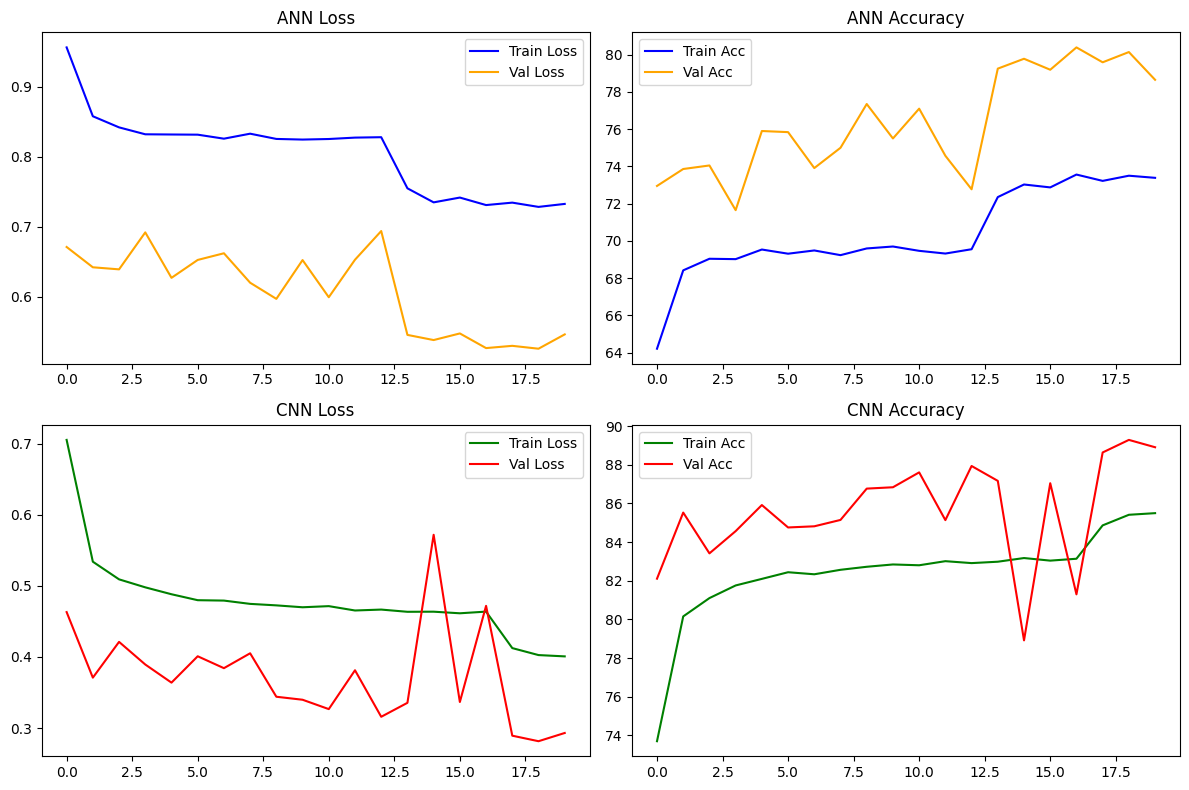

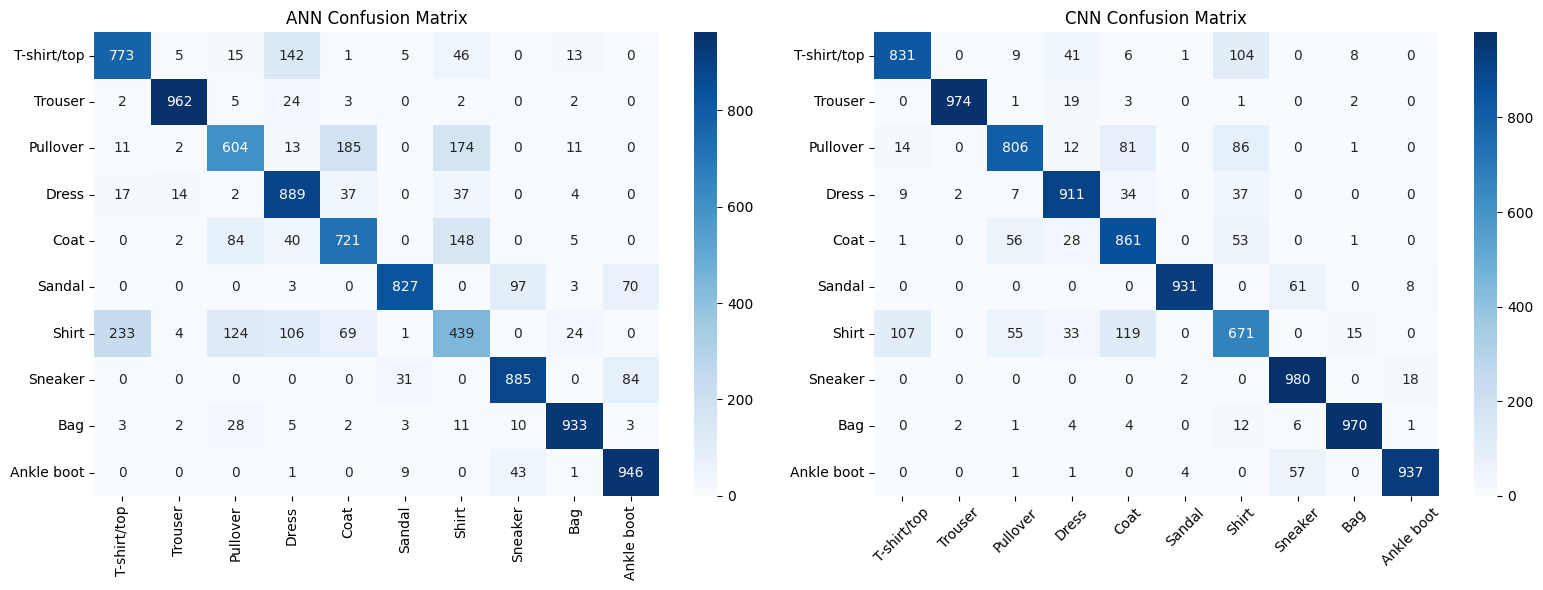


Per-Class Accuracy Comparison:

      Class  ANN Acc (%)  CNN Acc (%)
T-shirt/top         77.3         83.1
    Trouser         96.2         97.4
   Pullover         60.4         80.6
      Dress         88.9         91.1
       Coat         72.1         86.1
     Sandal         82.7         93.1
      Shirt         43.9         67.1
    Sneaker         88.5         98.0
        Bag         93.3         97.0
 Ankle boot         94.6         93.7

=== Analysis ===
Performance: CNN (88.72%) outperforms ANN (79.79%) by 8.93%. CNN captures spatial features better for images, while ANN ignores structure.

Key Confusions (instances > 50):
ANN: T-shirt/top -> Dress (142)
CNN: T-shirt/top -> Shirt (104)
ANN: Pullover -> Coat (185)
CNN: Pullover -> Coat (81)
ANN: Pullover -> Shirt (174)
CNN: Pullover -> Shirt (86)
ANN: Coat -> Pullover (84)
CNN: Coat -> Pullover (56)
ANN: Coat -> Shirt (148)
CNN: Coat -> Shirt (53)
ANN: Sandal -> Sneaker (97)
CNN: Sandal -> Sneaker (61)
ANN: Sandal -> Ankle bo

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
from torch.optim.lr_scheduler import ReduceLROnPlateau
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import pandas as pd  # For per-class table in analysis

# Set device for computation
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Step 1 & 2: Load Dataset and Preprocess
# Use Fashion-MNIST mean/std for normalization; augment training data only
train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),  # Mean and std for Fashion-MNIST
    transforms.RandomRotation(10),                # Slight rotation for variety
    transforms.RandomHorizontalFlip(p=0.5),       # Horizontal flip
    transforms.RandomCrop(28, padding=2)          # Small crop with padding
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Load full datasets
train_dataset_full = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=train_transform)
test_dataset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=test_transform)

# Create validation set: 50k train, 10k val from original 60k train
train_size = 50000
val_size = 10000
train_split, val_split_aug = random_split(train_dataset_full, [train_size, val_size])

# Use non-augmented val for fair evaluation
val_dataset_plain = torchvision.datasets.FashionMNIST(root='./data', train=True, download=False, transform=test_transform)
val_split_plain = torch.utils.data.Subset(val_dataset_plain, range(train_size, train_size + val_size))

# DataLoaders: Larger batch for efficiency
batch_size = 128
train_loader = DataLoader(train_split, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_split_plain, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# Class names
classes = ('T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot')
num_classes = len(classes)
input_size_ann = 28 * 28  # Flattened size for ANN

print(f"Data prepared: Train {len(train_split)}, Val {len(val_split_plain)}, Test {len(test_dataset)}")

# Step 3: Model Design
# Enhanced ANN: Deeper with BatchNorm and Dropout for better regularization
class EnhancedANN(nn.Module):
    def __init__(self, input_size, num_classes=10):
        super(EnhancedANN, self).__init__()
        self.fc1 = nn.Linear(input_size, 512)
        self.bn1 = nn.BatchNorm1d(512)
        self.fc2 = nn.Linear(512, 256)
        self.bn2 = nn.BatchNorm1d(256)
        self.fc3 = nn.Linear(256, 128)
        self.bn3 = nn.BatchNorm1d(128)
        self.fc4 = nn.Linear(128, num_classes)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = x.view(-1, input_size_ann)  # Flatten input
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = F.relu(self.bn2(self.fc2(x)))
        x = self.dropout(x)
        x = F.relu(self.bn3(self.fc3(x)))
        x = self.dropout(x)
        x = self.fc4(x)
        return x

# Enhanced CNN: Deeper conv layers with BatchNorm, Dropout, pooling
class EnhancedCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(EnhancedCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout2d(0.25)
        self.fc1 = nn.Linear(128 * 3 * 3, 256)  # Feature map size after 3 pools
        self.bn_fc1 = nn.BatchNorm1d(256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.dropout(x)
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.dropout(x)
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.dropout(x)
        x = x.view(-1, 128 * 3 * 3)  # Flatten
        x = F.relu(self.bn_fc1(self.fc1(x)))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# Instantiate models and move to device
ann_model = EnhancedANN(input_size_ann, num_classes).to(device)
cnn_model = EnhancedCNN(num_classes).to(device)

print(f"ANN parameters: {sum(p.numel() for p in ann_model.parameters()):,}")
print(f"CNN parameters: {sum(p.numel() for p in cnn_model.parameters()):,}")

# Training Function: Includes validation, RMSprop, and LR scheduler
def train_model(model, train_loader, val_loader, epochs=20, lr=0.01):  # Reduced epochs for readability
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.RMSprop(model.parameters(), lr=lr, alpha=0.9, weight_decay=1e-4)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

    # Lists to track metrics
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    best_val_acc = 0
    model_name = "ANN" if isinstance(model, EnhancedANN) else "CNN"

    for epoch in range(epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        correct_train, total_train = 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        # Compute averages
        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct_train / total_train
        train_losses.append(train_loss)
        train_accs.append(train_acc)

        # Validation phase
        model.eval()
        val_loss = 0.0
        correct_val, total_val = 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        val_loss_avg = val_loss / len(val_loader)
        val_acc = 100 * correct_val / total_val
        val_losses.append(val_loss_avg)
        val_accs.append(val_acc)

        # Scheduler step
        scheduler.step(val_loss_avg)

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f'best_{model_name.lower()}.pth')

        print(f'{model_name} Epoch {epoch+1}/{epochs}: Train Loss {train_loss:.4f}, Acc {train_acc:.2f}% | Val Loss {val_loss_avg:.4f}, Acc {val_acc:.2f}%')

    # Load best weights
    model.load_state_dict(torch.load(f'best_{model_name.lower()}.pth'))
    return train_losses, val_losses, train_accs, val_accs

# Evaluation Function: Test accuracy, confusion matrix, per-class accuracies
def evaluate_model(model, test_loader, model_name):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    accuracy = 100 * accuracy_score(all_labels, all_preds)
    cm = confusion_matrix(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, target_names=classes, output_dict=True)

    # Per-class recall (accuracy)
    class_acc = {classes[i]: round(report[cls]['recall'] * 100, 2) for i, cls in enumerate(classes)}

    print(f"\n{model_name} Test Accuracy: {accuracy:.2f}%")
    print(f"Per-Class Accuracies: {class_acc}")

    return accuracy, cm, class_acc

# Step 4: Train and Evaluate Models
print("\n--- Training Enhanced ANN ---")
ann_train_losses, ann_val_losses, ann_train_accs, ann_val_accs = train_model(ann_model, train_loader, val_loader)

print("\n--- Training Enhanced CNN ---")
cnn_train_losses, cnn_val_losses, cnn_train_accs, cnn_val_accs = train_model(cnn_model, train_loader, val_loader)

# Evaluate on test set
ann_acc, ann_cm, ann_class_acc = evaluate_model(ann_model, test_loader, "ANN")
cnn_acc, cnn_cm, cnn_class_acc = evaluate_model(cnn_model, test_loader, "CNN")

# Step 5: Visualizations
# Loss and Accuracy Curves
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
axs[0, 0].plot(ann_train_losses, label='Train Loss', color='blue')
axs[0, 0].plot(ann_val_losses, label='Val Loss', color='orange')
axs[0, 0].set_title('ANN Loss')
axs[0, 0].legend()

axs[0, 1].plot(ann_train_accs, label='Train Acc', color='blue')
axs[0, 1].plot(ann_val_accs, label='Val Acc', color='orange')
axs[0, 1].set_title('ANN Accuracy')
axs[0, 1].legend()

axs[1, 0].plot(cnn_train_losses, label='Train Loss', color='green')
axs[1, 0].plot(cnn_val_losses, label='Val Loss', color='red')
axs[1, 0].set_title('CNN Loss')
axs[1, 0].legend()

axs[1, 1].plot(cnn_train_accs, label='Train Acc', color='green')
axs[1, 1].plot(cnn_val_accs, label='Val Acc', color='red')
axs[1, 1].set_title('CNN Accuracy')
axs[1, 1].legend()

plt.tight_layout()
plt.show()

# Confusion Matrix Heatmaps
fig, axs = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(ann_cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes, ax=axs[0])
axs[0].set_title('ANN Confusion Matrix')

sns.heatmap(cnn_cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes, ax=axs[1])
axs[1].set_title('CNN Confusion Matrix')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Per-Class Comparison Table
class_names = list(classes)
comparison_data = {
    'Class': class_names,
    'ANN Acc (%)': [ann_class_acc[cls] for cls in class_names],
    'CNN Acc (%)': [cnn_class_acc[cls] for cls in class_names]
}
comparison_df = pd.DataFrame(comparison_data)
print("\nPer-Class Accuracy Comparison:\n")
print(comparison_df.to_string(index=False))

# Analysis: Concise summary of performance, confusions, and successes/failures
print("\n=== Analysis ===")
perf_diff = cnn_acc - ann_acc
print(f"Performance: CNN ({cnn_acc:.2f}%) outperforms ANN ({ann_acc:.2f}%) by {perf_diff:.2f}%. "
      f"CNN captures spatial features better for images, while ANN ignores structure.")

print("\nKey Confusions (instances > 50):")
threshold = 50
for i, true_class in enumerate(classes):
    for j, pred_class in enumerate(classes):
        if i != j:
            if ann_cm[i, j] > threshold:
                print(f"ANN: {true_class} -> {pred_class} ({ann_cm[i, j]})")
            if cnn_cm[i, j] > threshold:
                print(f"CNN: {true_class} -> {pred_class} ({cnn_cm[i, j]})")

print("\nSuccesses/Failures:")
print(f"- ANN succeeds on simple patterns (e.g., Trouser: {ann_class_acc['Trouser']:.2f}%) but fails on similar shapes (e.g., Shirt: {ann_class_acc['Shirt']:.2f}%).")
print(f"- CNN succeeds on textures (e.g., Sneaker: {cnn_class_acc['Sneaker']:.2f}%) but still struggles with visual overlaps (e.g., Coat: {cnn_class_acc['Coat']:.2f}%).")